# **Project 3 — Minimum Cost Connecting Paths**

We aim to design a **minimum-loss power transmission network** connecting a **central station** at $z_0$  to five **communities**, through intermediate points  $z_1, \dots, z_8.$

The quadratic objective function is given by:
$$
\min_{z_1,\dots,z_8} \;
\frac{\beta}{2}\sum_{k=0}^{4}\|z_{2k}-z_{2k+1}\|^2
+ \frac{\alpha}{2}\sum_{k=1}^{4}\|z_{2k-1}-z_{2k}\|^2,
$$
where $z_0$ and $z_9$ are fixed, and each $z_k$ belongs to its corresponding polygon region:
$$
z_k \in P_{1+\lfloor k/2 \rfloor}.
$$

---

### Polygon Definition (Second Form)

If a polygon is defined as the convex hull:
$$
P = \operatorname{conv}\{(a_1,b_1), \dots, (a_p,b_p)\},
$$
and the vertices are ordered **counter-clockwise**,  
then each edge corresponds to a linear constraint:
$$
(b_{k+1}-b_k)x + (a_k - a_{k+1})y \le a_k b_{k+1} - b_k a_{k+1}, \quad k = 1, \dots, p,
$$
where by convention:
$$
(a_{p+1}, b_{p+1}) := (a_1, b_1).
$$

---

### Notebook Tasks

The notebook will include the following steps:

- Construct polygons and their corresponding linear inequalities.  
- Formulate the QP matrices: $$G, c, A, b, A_e, b_e.$$  
- Implement a general QP solver (LP, unconstrained, equality-only, active-set).  
- For given data  
  $$z_0 = (4, 5), \quad z_9 = (26, 5), \quad \beta = 1,$$  
  compute solutions for various values of $\alpha.$
- Convert one polygon into a segment (equality constraint) and test the setup.


# Task 1 — Convexity, Coercivity, and boundary optimality

**Definitions (informal).**

- A function $$f:\mathbb{R}^m\to\mathbb{R}$$ is **convex** if for every $$x,y$$ and $$t\in[0,1]$$ we have
  $$
  f(tx+(1-t)y)\le t f(x)+(1-t) f(y).
  $$
  For twice-differentiable functions convexity is equivalent to the Hessian being positive semidefinite.

- A function $f$ is **coercive** if
  $$
  \|x\|\to\infty \quad\Longrightarrow\quad f(x)\to\infty.
  $$
  For a quadratic function $$f(x)=\tfrac12 x^T G x + c^T x + \text{const}$$ coercivity holds iff the quadratic form matrix $G$ is positive definite on the subspace of interest (i.e. has strictly positive smallest eigenvalue on that subspace).

---

## The objective written as a quadratic form

Let the optimization variables be the vector
$$
w = (x_1,y_1,x_2,y_2,\dots,x_8,y_8)\in\mathbb{R}^{16},
$$
where $$z_k=(x_k,y_k)$$ for $k=1,\dots,8$. The objective is
$$
f(w) \;=\; \frac{\beta}{2}\sum_{k=0}^{4}\|z_{2k}-z_{2k+1}\|^2
+ \frac{\alpha}{2}\sum_{k=1}^{4}\|z_{2k-1}-z_{2k}\|^2.
$$

Each term $$\tfrac{\gamma}{2}\|z_i-z_j\|^2$$ expands to a quadratic form in the components of $z_i$ and $z_j$. Therefore $f(w)$ is a **quadratic function** and can be written as
$$
f(w) = \tfrac12 w^T G w + c^T w + \text{const},
$$
for some symmetric matrix $$G\in\mathbb{R}^{16\times 16}$$ and vector $c\in\mathbb{R}^{16}$ (the constant and linear terms arise when one endpoint of a pair is fixed, e.g. $z_0$ or $z_9$ are given vecotrs).

---

## 1) Convexity

- ## First note that $f(w)=w^2$ is convex because

    Second-derivative proof:

    $ f(w)=w^{2},\quad f''(w)=2\ge 0 \text{ for all } w\in\mathbb{R}. $
    Therefore $f$ is convex.

    Direct convexity-inequality proof:

    $$ \lambda w_{1}^{2} + (1-\lambda) w_{2}^{2} - (\lambda w_{1} + (1-\lambda) w_{2})^{2} = \lambda(1-\lambda)(w_{1}-w_{2})^{2} \ge 0. $$

    So
    $$ (\lambda w_{1} + (1-\lambda) w_{2})^{2} \le \lambda w_{1}^{2} + (1-\lambda) w_{2}^{2}, $$
    which shows that $f(w)=w^{2}$ is convex.

-   ## Also, convexity is linear property, i.e. sum of convex functions is convex.

    **Claim.** If $f$ and $g$ are convex functions on a convex set $C\subset\mathbb{R}^n$, then the function $h:=f+g$ is convex on $C$.

    Proof:
    Recall $f$ is convex on $C$ iff for every $x,y\in C$ and every $t\in[0,1]$
    
    $$
    f(tx+(1-t)y)\le t\,f(x)+(1-t)\,f(y).
    $$

    The same inequality holds for $g$. Fix $x,y\in C$ and $t\in[0,1]$. Using convexity of $f$ and $g$ and then adding the two inequalities we obtain

    $$
    \begin{aligned}
    h(tx+(1-t)y) &= f(tx+(1-t)y)+g(tx+(1-t)y) \\
    &\le \big(t\,f(x)+(1-t)f(y)\big) + \big(t\,g(x)+(1-t)g(y)\big) \\
    &= t\big(f(x)+g(x)\big) + (1-t)\big(f(y)+g(y)\big) \\
    &= t\,h(x) + (1-t)\,h(y).
    \end{aligned}
    $$

    Since this holds for every $x,y\in C$ and every $t\in[0,1]$, $h$ is convex on $C$. ∎

    **Remark.** The same simple argument shows any nonnegative linear combination $ \alpha f + \beta g$ with $\alpha,\beta\ge0$ is convex, and by induction a finite sum of convex functions is convex.


Thus the combination gives **no guaranteed direction** for $h$.  
Therefore:

> **The difference of two convex functions is not necessarily convex.**

    ### Example showing failure
Let
$$f(x) = x^2, \qquad g(x) = 2x^2.$$
Both are convex.

But
$$h(x) = f(x)-g(x) = -x^2,$$
which is **concave**, not convex.

So $f-g$ need not be convex.

- Equipped with these two ideas above, and noting that in our objective funtion $f(w)$ which is a sum of squared terms each of which only has positive coefficients $α ≥ β = 1 $ by problem statement, the squared-norm term $$\|z_i-z_j\|^2$$ is convex in the pair $$(z_i,z_j)$$ (in fact strictly convex in the difference).  
- The objective is a nonnegative weighted sum of these convex terms with weights $\beta>0$ and $\alpha>0$.  
- Hence $f(w)$ is convex. Because the problem is quadratic, this is equivalent to the Hessian matrix $G$ being **positive semidefinite**.

More strongly: the variables $z_1,\dots,z_8$ lie on a path graph connected to fixed endpoints $z_0$ and $z_9$. The Hessian matrix for the variable block is a (weighted) graph Laplacian of this path (tensored with the $2\times2$ identity for the two coordinates). On the subspace of variable nodes, this reduced Laplacian is **positive definite** because the graph is connected and the end nodes are anchored (fixed). Therefore the quadratic form is **strictly convex** in the decision variables $w$. Strict convexity implies a unique unconstrained minimizer (if no constraints).

---

## 2) Coercivity

- For a quadratic function $$f(w)=\tfrac12 w^T G w + c^T w + \text{const}$$ coercivity follows from a bound of the form
  $$
  f(w) \ge \frac{\lambda_{\min}}{2}\|w\|^2 - C\|w\| - D
  $$
  where $\lambda_{\min}>0$ is the smallest eigenvalue of $G$ on the variable subspace. If $\lambda_{\min}>0$ then as $\|w\|\to\infty$ the quadratic term dominates and $f(w)\to\infty$.

- In our problem the reduced Hessian (on variables $z_1,\dots,z_8$) is the weighted Laplacian of a connected path with positive edge weights $\alpha,\beta$. A Laplacian of a connected graph has a single zero eigenvalue only when all nodes are free (corresponding to a global translation). Anchoring the two ends (fixed $z_0$ and $z_9$) removes the translation degree of freedom. Concretely, there is no nonzero direction in which all edge differences vanish while keeping fixed endpoints; hence the reduced Hessian is positive definite.

- Therefore the quadratic form has strictly positive curvature in every direction of the variable space and is **coercive**: $$\|w\|\to\infty\Rightarrow f(w)\to\infty.$$

Because the feasible set (product of five compact polygons) is closed and bounded, a coercive objective guarantees existence of a (unique) minimizer.

---

## 3) Why optimal points $z_1,\dots,z_8$ lie on polygon boundaries (generic argument)

Let each variable $z_k$ be constrained to the compact convex polygon $P_{1+\lfloor k/2\rfloor}$. Minimize the convex function $f$ over this Cartesian product of convex sets.

- **KKT (first-order) conditions.** For the constrained convex problem, a point $w^*$ is optimal iff there exist multipliers satisfying the Karush–Kuhn–Tucker conditions: the subgradient (here gradient) of the objective function at $w^*$ is a linear combination of active constraint normals, and complementary slackness holds. For each coordinate pair $(x_k,y_k)$, either
  1. the local gradient component with respect to $(x_k,y_k)$ vanishes and the point is **interior** to its polygon (no active inequalities at that vertex), or
  2. some polygon inequality is active at $z_k^*$ and that inequality’s normal balances the local gradient, so $z_k^*$ lies on the **boundary** with corresponding multiplier(s) nonzero.

- **Local optimality condition for a single node (intuitive).** If all other points $z_j$ are held fixed, the objective is quadratic in $z_k$ and its unconstrained minimizer is the weighted average of its neighbors (weights coming from $\alpha,\beta$). Concretely, the stationary condition for node $z_k$ (ignoring constraints) is a linear equation of the form
  $$
  \text{(sum of incident weights)}\cdot z_k \;=\; \sum (\text{weights}\times\text{neighbor positions}).
  $$
  If that weighted average lies inside the polygon assigned to $z_k$, then the unconstrained minimizer for that node is feasible and $z_k^*$ will be that interior point (and the corresponding local KKT multipliers are zero). Otherwise the unconstrained minimizer is infeasible and the constrained minimizer is the **projection** of that weighted average onto the polygon, which lies on the polygon **boundary** (or at a polygon vertex).

- **Generic outcome.** Unless the weighted-average (the unconstrained stationary point) for each node happens to fall strictly inside its polygon simultaneously (a nongeneric coincidence requiring precise alignment between polygon geometry and neighbors), at least one polygon constraint will be active. In practice for this problem the polygons are small regions around communities and the interaction with neighboring fixed points commonly pushes optimal $z_k$ to the polygon boundaries. Thus **generically** the optimal points sit on the boundaries of their respective polygons; interior solutions occur only in special symmetric or tuned cases where every local weighted-average falls inside its polygon.

---

### Summary (short)

- The objective is quadratic and (strictly) convex because it is a positive-weighted sum of squared distances on a connected path; the reduced Hessian is positive definite.  
- The objective is coercive: it grows like a positive multiple of $\|w\|^2$, so minimizers exist.  
- By KKT and the local-average characterization, each $z_k$ is either the interior weighted-average of its neighbors or its projection onto the polygon; generically the latter occurs, so optimal points lie on polygon boundaries.



# Task 2 — Constructing the QP matrices $G, c, A, b, A_e, b_e$

---

## 1. Quadratic Program (standard form)

A Quadratic Program can be written as
$$
\min_{w\in\mathbb{R}^n}\; q(w) \;=\; \frac{1}{2} w^T G w + c^T w
$$
subject to inequality and equality constraints
$$
A w \ge b,\qquad A_e w = b_e.
$$

Here $G\in\mathbb{R}^{n\times n}$ is symmetric, $c\in\mathbb{R}^n$.
$A\in\mathbb{R}^{m\times n}$, $b\in\mathbb{R}^m$ - matrices of inequality constarints.
$A_e\in\mathbb{R}^{p\times n}$ and $b_e\in\mathbb{R}^p$ - matrices of equality constarints.

---

## 2. Variable ordering and dimension for our network

We collect the decision points
$$
z_k=(x_k,y_k)\in\mathbb{R}^2,\quad k=1,\dots,8,
$$
into a single vector
$$
w = (x_1,y_1,x_2,y_2,\dots,x_8,y_8)\in\mathbb{R}^{16}.
$$
Thus $$n=16.$$ When we refer to variable indices, use the mapping
$$
\text{index}(x_k)=2(k-1),\qquad \text{index}(y_k)=2(k-1)+1.
$$

---

## 3. Writing the objective as a quadratic form

Each term of the objective is either of the form
$$
\frac{\gamma}{2}\|z_i-z_j\|^2 = \frac{\gamma}{2}\big((x_i-x_j)^2+(y_i-y_j)^2\big).
$$

Expanding the scalar quadratic yields contributions to the global matrices:

- If both $z_i$ and $z_j$ are decision variables, i.e. $i,j = 1,2,…, 8$, their contribution to $G$ (so that the objective equals $\tfrac12 w^T G w + c^T w + \text{const}$) is the block pattern for the two coordinates:
  - Let $I_2$ be the $2\times2$ identity. Then the $2×2$ blocks in rows/columns corresponding to $z_i$ and $z_j$ are:
    $$
    \begin{bmatrix}
    \text{at block }(i,i) & \text{at block }(i,j)\\[4pt]
    \text{at block }(j,i) & \text{at block }(j,j)
    \end{bmatrix}
    \leftarrow γ ⋅
    \begin{bmatrix}
    I_2 & -I_2\\[4pt]
    -I_2 & I_2
    \end{bmatrix}.
    $$
  - **In words: add $\gamma I_2$ to the diagonal blocks for $z_i$ and $z_j$, and add $-\gamma I_2$ to the off-diagonal blocks.**

- If one endpoint (say $z_j$) is fixed (e.g. $z_0$ or $z_9$), then contribution of the squared distance term to matrix $G$ is:
  - A diagonal block $\gamma I_2$ added to the variable block for $z_i$ (so part of $G$),
  - A linear term in $c$ equal to $-\gamma\,(z_j)$ placed in the two entries corresponding to $x_i,y_i$,
  - A constant term (which can be ignored for optimization).

- If both endpoints are fixed, there is only a constant contribution and nothing to $G$ or $c$.

**Therefore** the global assembly can be implemented by iterating over every pair that appears in the objective (internal pairs with weight $\beta$ and inter-community pairs with weight $\alpha$) and applying the above block updates.

---

## 4. Building $G$ and $c$ algorithmically (summary)

Algorithm (high level):

1. Initialize $G\leftarrow 0_{n\times n},\; c\leftarrow 0_n$.
2. For every term $$\tfrac{\gamma}{2}\|z_i-z_j\|^2$$ in the objective:
   - If both $i,j\in\{1,\dots,8\}$ are decision variables:
     - Let $$p = \text{index}(x_i),\quad q = \text{index}(y_i)$$ and similarly for $j$.
     - Update the four 2×2 blocks:
       $$G_{ii}\mathrel{+}= \gamma I_2,\quad G_{jj}\mathrel{+}=\gamma I_2,\quad G_{ij}\mathrel{-}= \gamma I_2,\quad G_{ji}\mathrel{-}= \gamma I_2.$$
   - If $i$ is variable, i.e. $i ∈\{1,2,…,8\}$, and $j$, i.e. $j ∈ \{0,9\}$, is fixed at coordinate $$\bar z_j=(\bar x_j,\bar y_j)$$:
     - Update diagonal block: $$G_{ii}\mathrel{+}= \gamma I_2.$$
     - Update linear term: $$c_{i}\mathrel{+}= -\gamma ⋅ \bar z_j$$ (applied to the two coordinates).
   - If both fixed: ignore (constant only).

3. After processing all terms, ensure $G$ is symmetric (numerical assembly should already ensure symmetry).

This produces a symmetric $G$ and vector $c$ that represent the original objective in QP form.

---

## 5. Constructing constraints $A, b$ (matrices of inequalities) and $A_e, b_e$ (matrices of equalities)

Each decision point $z_k=(x_k,y_k)$ is constrained to lie in a polygon or a geometric set. **Polygons are given as convex hulls of vertices in counter-clockwise order**. For a polygon
$$
P=\operatorname{conv}\{(a_1,b_1),\dots,(a_p,b_p)\},
$$
compute for each edge the linear inequality
$$
(b_{k+1}-b_k)\,x + (a_k-a_{k+1})\,y \le a_k b_{k+1} - b_k a_{k+1},
\qquad k=1,\dots,p,
$$
where $(a_{p+1},b_{p+1}):=(a_1,b_1)$.

To turn these into rows of $$A w \ge b$$ (note the QP statement used $Aw\ge b$ — you can convert either direction; here we keep the stated sign), do the following for each inequality row for polygon of point $z_k$:

- Build a row vector $r\in\mathbb{R}^n$ with zeros everywhere except the two entries corresponding to $x_k,y_k$, where you place the coefficients $[b_{k+1}-b_k,\; a_k-a_{k+1}]$.
- Append $r$ as a row to matrix $A$, and append the scalar right-hand side $a_k b_{k+1} - b_k a_{k+1}$ to vector $b$.

Equality constraints (e.g., if a polygon is replaced by a line segment) are handled similarly: for a line defined by two points $(u,v)$ and $(u',v')$ the line equation is
$$
(v'-v)\,x + (u-u')\,y = u v' - v u',
$$
and we append this as a row in $A_e$ with corresponding entry in $b_e$. If you must also restrict to the segment endpoints (boundedness along the line), you can add inequalities for parameter bounds; otherwise using a pure equality tests solver handling of equality constraints.

---

## 6. Practical notes and corner cases

- **Indexing care:** We need to keep careful mapping between point index and block index in $w$ to avoid bugs.
- **Units and weights:** The coefficients $\alpha,\beta$ are positive; they scale contributions to $G$. With correct assembly the reduced Hessian on variable space will be positive definite (as we have a connected graph, anchored ends).
- **Inequality orientation:** The derived edge inequality above is of the form (linear expression) $\ge$ (RHS). If the solver we are going to employ later expects the opposite sign (e.g. $A w \le b$), we need to flip signs accordingly.
- **Numerical symmetry:** After sum-assembling blocks, enforce symmetry by replacing $$G\leftarrow (G+G^T)/2$$ to avoid small round-off asymmetries.
- **Fixed endpoints:** When an endpoint is fixed, treat its contribution to the objective as described (diagonal blocks + linear term). Do not include fixed coordinates($z_0, z_9)$ in the decision vector $w$.

---

## 7. Pseudocode summary



In [1]:
# Here we implement the goals in Task 2;
# we define a function build_QP_matrices(...) --> G,c,A,b,Ae,be

import numpy as np
from typing import List, Tuple

dtype = float
# alpha = 2
# beta = 1
n = 16

def idx(k): # k = 1,2,..., 8
  # returns the corresponding w index
  base = 2*(k-1)
  return base, base+1

def objective_terms(alpha: float, beta: float) -> List[Tuple[float,int,int]]: # step 3
    """
    Return list of triples (gamma, i, j) representing terms
    (gamma/2) * ||z_i - z_j||^2 in the objective.

    Indices: 0 -> z0 (fixed), 1..8 -> variables, 9 -> z9 (fixed).
    """
    terms = []
    # internal community pairs: k = 0..4 -> (z_{2k}, z_{2k+1})
    for k in range(5):
        i = 2*k
        j = 2*k + 1
        terms.append((beta, i, j))   # store gamma = beta (not beta/2)
    # between-community pairs: k = 1..4 -> (z_{2k-1}, z_{2k})
    for k in range(1,5):
        i = 2*k - 1
        j = 2*k
        terms.append((alpha, i, j))  # store gamma = alpha
    return terms
def add_var_var_block(G, gamma, i, j):
    """Add contributions to G for a pair of variable indices (i,j)."""
    # Adjust indices for 0-based array indexing based on problem statement's 1-8 variable indexing
    # i and j are 1-8 for variables
    for p in range(2):  # x,y coordinates
        G[2*(i-1)+p, 2*(i-1)+p] += gamma
        G[2*(j-1)+p, 2*(j-1)+p] += gamma
        G[2*(i-1)+p, 2*(j-1)+p] -= gamma
        G[2*(j-1)+p, 2*(i-1)+p] -= gamma

    return G

def add_var_fixed_block(G, c, gamma, var_idx, z_fixed_coords):
    """Add contributions when one endpoint is fixed.
    z_fixed_coords is the (x,y) tuple of the fixed point.
    """
    base = 2*(var_idx-1)
    G[base:base+2, base:base+2] += gamma * np.eye(2)
    c[base:base+2] -= gamma * np.array(z_fixed_coords)

    return G, c

def polygon_to_constraints(vertices, varxy_k):
  # makes a row of inequality/equality constraints for a given ploygon with vertices
  global n
  number_vertices = len(vertices)
  # print(f"Number of vertices: {number_vertices}")
  if number_vertices > 2: # in this case number_vertices = number_edges
    A_rows = list()
    b_rows = list()
    for i in range(number_vertices):
      a1, b1 = vertices[i]
      a2, b2 = vertices[i+1] if i+1 < number_vertices else vertices[0]
      coef_x = b2 - b1
      coef_y = a1 - a2
      rhs = a1 * b2 - b1 * a2
      row = np.zeros(n)
      (wx, wy) = idx(varxy_k)
      row[wx] = coef_x
      row[wy] = coef_y
      A_rows.append(row)
      b_rows.append(rhs)
    return A_rows, b_rows

  elif number_vertices == 2: # number_vertices=2 > 1=number_edges as there's only one line connecting 2 pts
    # possible cases p = [(a1,b1), (a2,b2)], [(a1,b1)] or []
    Ae_rows = list()
    be_rows = list()
    for i in range(number_vertices-1):
      a1, b1 = vertices[i] # bu holda uzi bizda p = [(a1,b1), (a2,b2)], [(a1,b1)] or [], so o'yla
      a2, b2 = vertices[i+1] if i+1 < number_vertices else vertices[0]
      coef_x = b2 - b1
      coef_y = a1 - a2
      rhs = a1 * b2 - b1 * a2
      row = np.zeros(n)
      (wx, wy) = idx(varxy_k)
      row[wx] = coef_x
      row[wy] = coef_y
      Ae_rows.append(row)
      be_rows.append(rhs)
    return Ae_rows, be_rows

  else:
    raise ValueError("Polygon must have at least 2 vertices")
    # print("Polygon must have at least 2 vertices")
    # return None, None



def build_QP_matrices(polygons, alpha, beta, z0_coords, z9_coords) -> list:
  global n
  G = np.zeros((n,n), dtype=dtype)
  c = np.zeros(n, dtype=dtype)
  A = list()
  b = list()
  Ae = list()
  be = list()

  variables = set(range(1, 9)) # Indices 1 through 8 are variables
  fixed_point_coords_map = {0: z0_coords, 9: z9_coords}

  for gamma, i, j in objective_terms(alpha, beta):
    # print(f"Processing term: gamma={gamma}, i={i}, j={j}") # Debugging print
    if i in variables and j in variables:
        add_var_var_block(G, gamma, i, j)
    elif i in variables and j in fixed_point_coords_map: # j is a fixed point (0 or 9)
        add_var_fixed_block(G, c, gamma, i, fixed_point_coords_map[j])
    elif j in variables and i in fixed_point_coords_map: # i is a fixed point (0 or 9)
        add_var_fixed_block(G, c, gamma, j, fixed_point_coords_map[i])
    # If both i and j are fixed (e.g., z0-z9, though not in objective_terms directly), ignore (constant term only)

  # Assembling the constraints of all polygons into one big contraint matrix:
  k = 1 # to count which polygon we're in
  for polygon in polygons:
    numnodes = len(polygon)
    numpolygones = len(polygons)
    if numnodes > 2:
      if polygon == polygons[0] or polygon == polygons[-1]: # first and last ploygs have only one variable z1, and z8 in them respectively
        A_rows_k, b_rows_k = polygon_to_constraints(polygon, k)
        A.extend(A_rows_k)
        b.extend(b_rows_k)
        k = k + 1
      else:
        A_rows_k, b_rows_k = polygon_to_constraints(polygon, k)
        A.extend(A_rows_k)
        b.extend(b_rows_k)
        k = k + 1
        A_rows_k, b_rows_k = polygon_to_constraints(polygon, k)
        A.extend(A_rows_k)
        b.extend(b_rows_k)
        k = k + 1

    elif numnodes == 2:
      if polygon == polygons[0] or polygon == polygons[-1]: # first and last ploygs have only one variable z1, and z8 in them respectively
        Ae_rows_k, be_rows_k = polygon_to_constraints(polygon, k)
        Ae.extend(Ae_rows_k)
        be.extend(be_rows_k)
        k = k + 1
      else:
        Ae_rows_k, be_rows_k = polygon_to_constraints(polygon, k)
        Ae.extend(Ae_rows_k)
        be.extend(be_rows_k)
        k = k + 1
        Ae_rows_k, be_rows_k = polygon_to_constraints(polygon, k)
        Ae.extend(Ae_rows_k)
        be.extend(be_rows_k)
        k = k + 1
    else:
      raise ValueError("Polygon must have at least 2 vertices")

  # converting lists to numpy arrays; keep <= form
  A_le = np.array(A) if A else np.zeros((0,n))
  b_le = np.array(b) if b else np.zeros((0,))
  Ae = np.array(Ae) if Ae else np.zeros((0,n))
  be = np.array(be) if be else np.zeros((0,))
  # optionally produce >= form:
  A_ge = -A_le; b_ge = -b_le

  # return G, c, A_le, b_le, Ae, be  # or include A_ge, b_ge if A >= b is ineqty requiremnt
  return G, c, A_ge, b_ge, Ae, be  # here returning A_ge, b_ge as A >= b is ineqty requiremnt by prob statement
  # return G, c, A, b, Ae, be

# Defining Global Variables, z0, z9, polygons here if wanted


if __name__ == "__main__":
    # Define fixed coordinates as per problem statement
    z0 = (4, 5)
    z9 = (26, 5)

    # Polygons defined
    p0 = [(2, 1), (6.2, 2.8), (7.7, 7.9), (2, 8), (0.4, 4.5)]
    p1 = [(9.9, 3.6), (11.6, 2.7), (13.2, 5.7), (10.4, 6.3)]
    p2 = [(15.5, 5.7), (16.3, 3.4), (18.2, 4.3), (18.2, 7.5), (16.1, 7.6)]
    p3 = [(21.6, 0.8), (23.5, 9.5), (21.7, 7.7)]
    # p3 = [(21.6, 0.8), (23.5, 9.5)]
    p4 = [(23.7, 5.5), (24.9, 3.7), (27.6, 5.6), (25, 6.7)]
    polygons = [p0, p1, p2, p3, p4]
    # print(polygon_to_constraints(p3, 7))

    # Call the function with actual fixed coordinates
    G, c, A_ge, b_ge, Ae, be  = build_QP_matrices(polygons, alpha=4, beta=1, z0_coords=z0, z9_coords=z9)
    # print(A_le.shape) # A_le.shape = (33,16) is right as 5+(4+4)+(5+5)+(3+3)+(4)=33
    # print(b_le.shape[0] == A_le.shape[0])
    print(Ae, be)
    # print(Ae.shape[0] == be.shape[0])
    # print(objective_terms(alpha=2.0, beta=1.0))

[] []


# Task 3 — Solver design and algorithm

This cell describes the solver design for the Quadratic Program
$$
\min_{w\in\mathbb{R}^n}\; q(w)=\tfrac12 w^\top G w + c^\top w
$$
subject to inequalities and equalities. We adopt the **internal convention**
that inequalities are handled in the $\le$ form:
$$
A_{\text{ineq}}\,w \ge b_{\text{ineq}},
$$
which is NOT compatible with SciPy's `linprog` and many solvers. Because QP polygon inequality data and explanations in the textbook are in the form $A w \ge b$, we are staying consitent with $Aw ≥ b$ , and we can convert it to $Aw ≤ b$ by multiplying rows by $-1$ if we need to.

---

## Objectives for the solver function

Implement a function with signature similar to
**solve_qp(G, c, A=None, b=None, A_e=None, b_e=None, tol=1e-9, max_iter=500)**
that handles four cases:

a. **Linear Program (LP)** when $$G\approx 0$$.  
b. **Unconstrained QP**: no inequalities and no equalities.  
c. **Equality-only QP**: only $$A_e w = b_e$$.  
d. **Inequality QP**: at least one inequality present — solved by an **Active-Set** method (with robust fallbacks).

Below are the design ideas, KKT structure, algorithmic steps, and practical steps that we do:

---

## Branch detection (routing)

- Compute a small norm to decide if $G$ is essentially zero:
  $$
  \text{is\_LP} \Longleftarrow \|G\|_\infty < \epsilon_G,\quad \epsilon_G\approx 10^{-12}.
  $$
- Determine if there are constraints:
  - No constraints if both inequality and equality matrices are empty (shapes `(0,n)`).
  - Equality-only if inequalities empty but equality non-empty.
  - Inequality-present otherwise.

Route to the correct solver branch accordingly.

---

## Branch (a): LP (use a standard LP solver)

When $G$ is numerically zero, solve the linear program
$$
\min\; c^\top w \quad\text{s.t.}\quad A_{\text{ineq}} w \ge b_{\text{ineq}},\quad A_e w = b_e.
$$

**Implementation notes**
- We use `scipy.optimize.linprog` (method `'highs'`) with `A_ub=-A_ineq, b_ub=-b_ineq, A_eq=A_e, b_eq=b_e`.
- We need to check `res.success` and return `res.x`. If it fails, report error and try small regularization or alternative solver.

---

## Branch (b): Unconstrained QP

If there are no constraints, solve stationarity equation:
$$
G w + c = 0 \quad\Longrightarrow\quad w = -G^{-1} c.
$$

**Practical points**
- If `G` is invertible: use `numpy.linalg.solve(G, -c)`.
- If `G` is singular or ill-conditioned: use pseudoinverse $w = -\mathrm{pinv}(G) c$ or `lstsq` solver, and we need to verify stationarity: residual $\|G w + c\|$ is small.

---

## Branch (c): Equality-only QP (KKT system)

Solve the Karush–Kuhn–Tucker (KKT) linear system for equalities:
$$
\begin{bmatrix} G & A_e^\top \\ A_e & 0 \end{bmatrix}
\begin{bmatrix} w \\ \lambda \end{bmatrix}
=
\begin{bmatrix} -c \\ b_e \end{bmatrix}.
$$

**Implementation notes**
- Verify if $G$ is symmetric by: $$G\leftarrow\tfrac12(G+G^\top)$$.
- Solve the full KKT system with `numpy.linalg.solve`. If ill-conditioned, add small regularization $G+\epsilon I$ (e.g. $\epsilon=10^{-12}$).
- Return $w$ (and multipliers $\lambda$ if desired).

---

## Branch (d): Inequality QP — Active-Set method (high-level)

Active-set maintains a set of inequality indices treated as equalities. Each iteration:

1. **Feasible starting point**:
   
      Find $w^{(0)}$ such that
      $$
      A_{\text{ineq}} w^{(0)} \ge b_{\text{ineq}},\qquad A_e w^{(0)} = b_e.
      $$
      One practical approach for this is: use the centroid (mean of vertices) of each polygon for each point $z_k$ to create a feasible $w^{(0)}$ (the centroid of a convex polygon lies inside it).

2. **Initialize active set:**

     $\mathcal{A}$ as those inequality indices where $$A_i w^{(0)} \approx b_i$$ (within tolerance).

3. **Iterate**:
  - Form the combined equality matrix
  $$
  A_{\text{comb}} =
  \begin{bmatrix} A_e \\ A_{\mathcal{A}} \end{bmatrix},\qquad
  b_{\text{comb}} = \begin{bmatrix} b_e \\ b_{\mathcal{A}} \end{bmatrix}.
  $$
  - Solve the KKT system for the equality-constrained QP:
  $$
  \begin{bmatrix} G & A_{\text{comb}}^\top \\ A_{\text{comb}} & 0 \end{bmatrix}
  \begin{bmatrix} w \\ \lambda \end{bmatrix}
  =
  \begin{bmatrix} -c \\ b_{\text{comb}} \end{bmatrix}.
  $$
  Extract multipliers associated with active inequalities (call them $\nu$).
- **Feasibility check**: compute violations
  $$
  v := A_{\text{ineq}} w - b_{\text{ineq}}.
  $$
  
  If $$\max(v) > \text{tol_feas}$$
  
  add the most violated constraint index to $\mathcal{A}$ and continue.
- **Optimality check**: if all active multipliers satisfy $$\nu \ge -\text{tol_mult}$$
(nonnegative within tolerance), then $w$ is optimal. Otherwise remove the most negative-multiplier constraint from $\mathcal{A}$ and continue.

4. **Termination**: stop when KKT optimality and feasibility satisfied or when iteration limit reached.

**Key implementation details**
- Feasibility tolerance `tol_feas ≈ 1e-8`.  
- Multiplier tolerance `tol_mult ≈ 1e-10`.  
- When solving KKT, we need to handle singularity by tiny regularization if needed.  
- To prevent cycling, we need to cap iterations and keep fallback solver (e.g., `scipy.optimize.minimize` with `trust-constr`) as a robust backup.

---

## Feasible starting point (practical for this set of polygons, as they're all convex as shown in Task 1.)

Because each variable $z_k$ is constrained to a convex polygon, the **centroid** (mean of vertices) is guaranteed to lie inside the polygon (for strictly convex polygons, inside; for borderline cases it may lie on boundary). We construct $w^{(0)}$ by concatenating centroids of the 8 variable polygons. This gives a reliable feasible start in our geometric problem and avoids implementing a Phase-I LP.

---

## Numerical and debugging checks

- **Symmetry**: enforce $$G\leftarrow\tfrac12(G+G^\top)$$ before solvers eve if we are sure we're receiving a symmmetric G from the functon build_QP_matrices from Task 2.  
- **Shapes**: verify `G.shape == (n,n)`, `c.shape == (n,)`, `A.shape[1] == n`, `A_e.shape[1] == n`.  
- **Sanity checks**: compute `max_violation = np.max(A @ w - b)` and KKT residual `r = G @ w + c + A_e.T @ mu + A_active.T @ nu`. Both should be small at optimum.  
- **Unit tests**: (need to work on this with Dr. Forbes on Friday) test each branch on small toy problems:
  - LP: set `G = 0` and use simple box constraints.
  - Unconstrained: random SPD `G` and `c`.
  - Equality-only: random SPD `G`, single equality `1^T w = const`.
  - Active-set: use the full network QP and verify feasible start works.

---

## Fallback option

If active-set has trouble (cycling, no feasible start, KKT singularities), use a robust general-purpose constrained optimizer as fallback:
- `scipy.optimize.minimize(obj, x0, method='trust-constr', constraints=...)` with analytic gradient `grad = G @ w + c`. This is slower but often reliable for small problems.

---

## Outputs and diagnostic information

We want to have our solver `solve_qp(data, method = "active set")` return:
- `w_opt` (primary),
- optionally Lagrange multipliers `(mu, nu)` if desired,
- `active_set` at termination,
- solver status (success/failure), and
- diagnostic info: `kkt_residual`, `max_violation`, `iterations`.

Printing or saving these diagnostics helps us debug and validate our solver correctness.

---

# Phase I Method for Constructing an Initial Feasible Point

In general quadratic programming, finding a feasible point can be difficult if the
constraints are complicated or if we do not have a geometric description of the feasible set.  
To handle this, Nocedal–Wright propose a **Phase I feasibility LP**.

We assume our QP has the form

\[
\begin{aligned}
\text{minimize}   &\quad \tfrac12 x^T G x + c^T x \\
\text{subject to} &\quad a_i^T x = b_i, \quad i \in E, \\
                  &\quad a_i^T x \ge b_i, \quad i \in I.
\end{aligned}
\]

The idea is:  
we introduce slack variables $ z_i \ge 0 $ that measure the amount by which a constraint is violated.  
If we can drive all $z_i$ to zero, the corresponding $x$ is feasible.

---

## Step 1 — Choose an initial estimate $\tilde{x}$

This can be anything:
- a random point,
- the centroid of the bounding box,
- or a user-supplied guess.

The point does *not* need to be feasible.

---

## Step 2 — Define the feasibility LP

We solve the following auxiliary linear program:

\[
\begin{aligned}
\min_{x,z}\quad & e^T z \\
\text{s.t.}\quad
& a_i^T x + \gamma_i z_i = b_i, \quad i \in E, \\
& a_i^T x + \gamma_i z_i \ge b_i, \quad i \in I, \\
& z_i \ge 0.
\end{aligned}
\]

Here:

- $e = (1,\dots,1)^T$.
- For equality constraints:
$
\gamma_i = -\mathrm{sign}(a_i^T \tilde{x} - b_i).
$
This ensures the slack $z_i$ always reduces the violation.
- For inequality constraints:
$
\gamma_i = 1.
$

---

## Step 3 — A feasible point for the feasibility LP

Nocedal–Wright show that the LP always admits the feasible point

$
x = \tilde{x},
$

$
z_i = |a_i^T \tilde{x} - b_i|, \quad i\in E,
$

$
z_i = \max(b_i - a_i^T \tilde{x}, 0), \quad i\in I.
$

Verification:
- If a constraint is satisfied, the corresponding $z_i$ becomes zero.
- If a constraint is violated, the corresponding $z_i$ becomes exactly the violation amount.

---

## Step 4 — Solve the feasibility LP

If the original QP has at least one feasible point,  
**the optimal value of this LP is zero.**

Then the optimal $(x^*, z^* = 0)$ gives a feasible point for the original QP.

---

## Step 5 — Use this feasible point

The resulting feasible point becomes:

- the starting point for Phase II (actual QP),
- and determines the initial working set $W_0$ in the active-set method.

---

## Summary

The Phase I feasibility LP converts constraint violations into slack variables and
systematically drives them to zero. This method is general and works even when
the geometry of the feasible region is complicated or unknown.

You can implement this method inside your `initial_feasible_point()` function:

1. Pick a guess $\tilde{x}$.
2. Compute all violations.
3. Build the feasibility LP matrices.
4. Solve using any LP solver.
5. Extract the feasible $x$-part and return it.



res: Optimization terminated successfully. (HiGHS Status 7: Optimal)
w0_sol [ 2.   1.   9.9  3.6  9.9  3.6 15.5  5.7 15.5  5.7 23.5  9.5 21.6  0.8
 24.9  3.7]
We're in solve_qp
number of equality constraints, rows of matrix A_e:  0
number of inequality constraints, rows of matrix A_ge:  33
w0: [ 2.   1.   9.9  3.6  9.9  3.6 15.5  5.7 15.5  5.7 23.5  9.5 21.6  0.8
 24.9  3.7]
w_opt: [ 7.0299737   5.62191057 10.23970581  5.43441137 13.2         5.7
 15.5         5.7        18.2         5.59616581 21.66875723  5.54424871
 22.63233188  5.52699335 23.78550602  5.37174097]


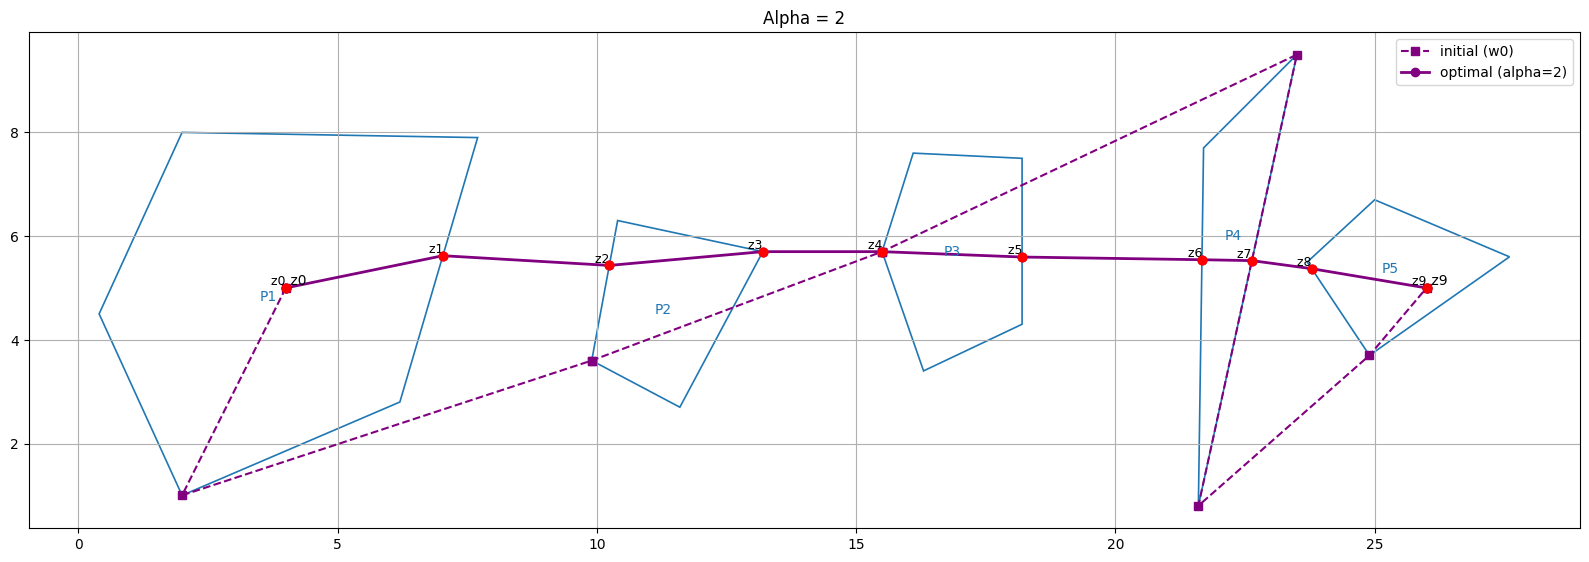

In [8]:
# Phase-I and Centroid example to get initial feasible point (Aw >= b, adn Ae*w =be constraints x n=16 variables)
import numpy as np
from scipy.optimize import linprog

def get_centroid(polygons):
    """
    Build a centroid-based guess vector of length n=16.
    polygons: list of polygons (each polygon is list/array of (x,y) pairs).
    poly_map: function k -> polygon_index for z_k, k=1..8. If None, default (k-1)//2.
    Returns: centroid numpy array shape (16,)
    """
    n_vars = 16
    midpoints = []
    w_center = []
    k = 0
    for poly in polygons:
      verts = np.array(poly)
      cx, cy = verts.mean(axis=0)
      if poly == polygons[0] or poly == polygons[-1]:
        w_center.append(cx)
        w_center.append(cy)
        k += 2
      else:
        w_center.append(cx)
        w_center.append(cy)
        k += 2
        w_center.append(cx)
        w_center.append(cy)
        k += 2
      midpoints.append((cx, cy))
    # return midpoints, w_center
    return np.array(w_center)


def get_initial_feasible_point(A_ge, b_ge, Ae, be,
                           polygons=None, z0=None, z9=None,
                           method='phase-i lp', tol_phase1=1e-8):
    """
    Getting initial feasible point with the chosen method,
    method = "Phase-I LP" or "centroid" to find a feasible w0.
    Returns: (w0_sol, is_feasible_bool, lp_result_object)
    Minimal changes from your original function: uses get_centroid() above.
    """
    global n
    eq_mat_len = 0 if Ae is None or Ae.size == 0 else Ae.shape[0]
    ineq_mat_len = 0 if A_ge is None or A_ge.size == 0 else A_ge.shape[0]

    if eq_mat_len > 0 or method == "centroid":
        w0 = get_centroid(polygons)
        res = {"message": """Getting feasible point w0 terminated successfully with "centroid" method, as there's equality contraint or "centroid" method chosen""",
               "success": True,
               "status": 1}
        return w0, True, res
    else:
        # --- Build a centroid-based initial guess if polygons supplied ---
        x_tilde = get_centroid(polygons)
        # print("x_tilde:", x_tilde)

        # compute gamma_i (length eq + ineq)
        gamma = np.ones(eq_mat_len + ineq_mat_len)
        for i in range(eq_mat_len):
            a_dot = float(Ae[i].dot(x_tilde))
            gam = -np.sign(a_dot - be[i])
            gamma[i] = gam if gam != 0 else 1.0

        # Build LP variables: [w (len n) ; z (len = eq+ineq)]
        n_total = n + len(gamma)
        c_lp = np.concatenate([np.zeros(n), np.ones(len(gamma))])

        A_ub_rows = []
        b_ub_rows = []
        A_eq_rows = []
        b_eq_rows = []

        # equality constraints: Ae * w + gamma_i z_i = be  (for i in equality block)
        for i in range(eq_mat_len):
            row = np.zeros(n_total)
            row[:n] = Ae[i]
            row[n + i] = gamma[i]
            A_eq_rows.append(row)
            b_eq_rows.append(be[i])

        # inequality constraints: A_ge * w + gamma z >= b_ge -> -A_ge w - gamma z <= -b_ge
        for i in range(ineq_mat_len):
            row = np.zeros(n_total)
            row[:n] = -A_ge[i]
            row[n + eq_mat_len + i] = -gamma[eq_mat_len + i]
            A_ub_rows.append(row)
            b_ub_rows.append(-b_ge[i])

        # bounds: w free, z >= 0
        bounds = []
        for _ in range(n):
            bounds.append((None, None))
        for _ in range(len(gamma)):
            bounds.append((0, None))

        A_ub = np.array(A_ub_rows) if A_ub_rows else None
        b_ub = np.array(b_ub_rows) if b_ub_rows else None
        A_eq = np.array(A_eq_rows) if A_eq_rows else None
        b_eq = np.array(b_eq_rows) if b_eq_rows else None

        # Solve Phase-I LP
        res = linprog(c_lp, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

        sol = res.x
        w0_sol = sol[:n]
        z_sol = sol[n:]
        feasible_by_phase1 = z_sol.sum() <= tol_phase1

        if feasible_by_phase1 and res.success:
            return w0_sol, True, res
        else:
            # Phase-I found positive slack or res.suceess=False, i.e. LP didn't work well. Try centroid fallback (if available)
            w0_sol = get_centroid(polygons)
            res = {"message": """Getting feasible point w0 terminated successfully with "centroid" method.
                                as error occured in Phase-I LP so "centroid" method chosen as a back up""",
                "success": True,
                "status": 1}
            return w0_sol, True, res


if __name__ == "__main__":
  # Define fixed coordinates as per problem statement
  z0 = (4, 5)
  z9 = (26, 5)

  # Polygons defined
  p0 = [(2, 1), (6.2, 2.8), (7.7, 7.9), (2, 8), (0.4, 4.5)]
  p1 = [(9.9, 3.6), (11.6, 2.7), (13.2, 5.7), (10.4, 6.3)]
  # p1 = [(9.9, 3.6), (11.6, 2.7)]
  p2 = [(15.5, 5.7), (16.3, 3.4), (18.2, 4.3), (18.2, 7.5), (16.1, 7.6)]
  p3 = [(21.6, 0.8), (23.5, 9.5), (21.7, 7.7)] # Reverting p3 to a 3-vertex polygon for inequality setup
#   p3 = [(21.6, 0.8), (23.5, 9.5)] # This makes it an equality constraint (a line segment)
  p4 = [(23.7, 5.5), (24.9, 3.7), (27.6, 5.6), (25, 6.7)]

  polygons = [p0, p1, p2, p3, p4]


  # Re-build QP matrices for a specific alpha and beta
  G, c, A_ge_test, b_ge_test, Ae_test, be_test = build_QP_matrices(polygons, alpha=2, beta=1, z0_coords=z0, z9_coords=z9)
  # Solve the get_initial_feasible_ponit(...) with chosen method = "phase-i lp" or "centroid"
  methods = ["phase-i lp", "centroid"]
  w0_sol, is_small_z, res = get_initial_feasible_point(A_ge=A_ge_test, b_ge=b_ge_test, Ae=Ae_test, be=be_test,
                                                     polygons=polygons, z0=z0, z9=z9, method=methods[0])
  print("res:", res["message"])
  print("w0_sol", w0_sol)
  plot_different_alphas(polygons, z0, z9, alphas=[2], colors=["purple"])


We're in solve_qp
number of equality constraints, rows of matrix A_e:  0
number of inequality constraints, rows of matrix A_ge:  0
we're in unconstrained QP, branch b
w0:  None
w_opt:  [ 7.66666667  5.          8.58333333  5.         12.25        5.
 13.16666667  5.         16.83333333  5.         17.75        5.
 21.41666667  5.         22.33333333  5.        ]
We're in solve_qp
number of equality constraints, rows of matrix A_e:  0
number of inequality constraints, rows of matrix A_ge:  33
w0: [ 2.   1.   9.9  3.6  9.9  3.6 15.5  5.7 15.5  5.7 23.5  9.5 21.6  0.8
 24.9  3.7]
w_opt: [ 7.15535295  6.04820002 10.27495048  5.62473259 13.2         5.7
 15.5         5.7        18.2         5.59586419 21.66912797  5.56983024
 22.65972975  5.65244675 23.7         5.5       ]


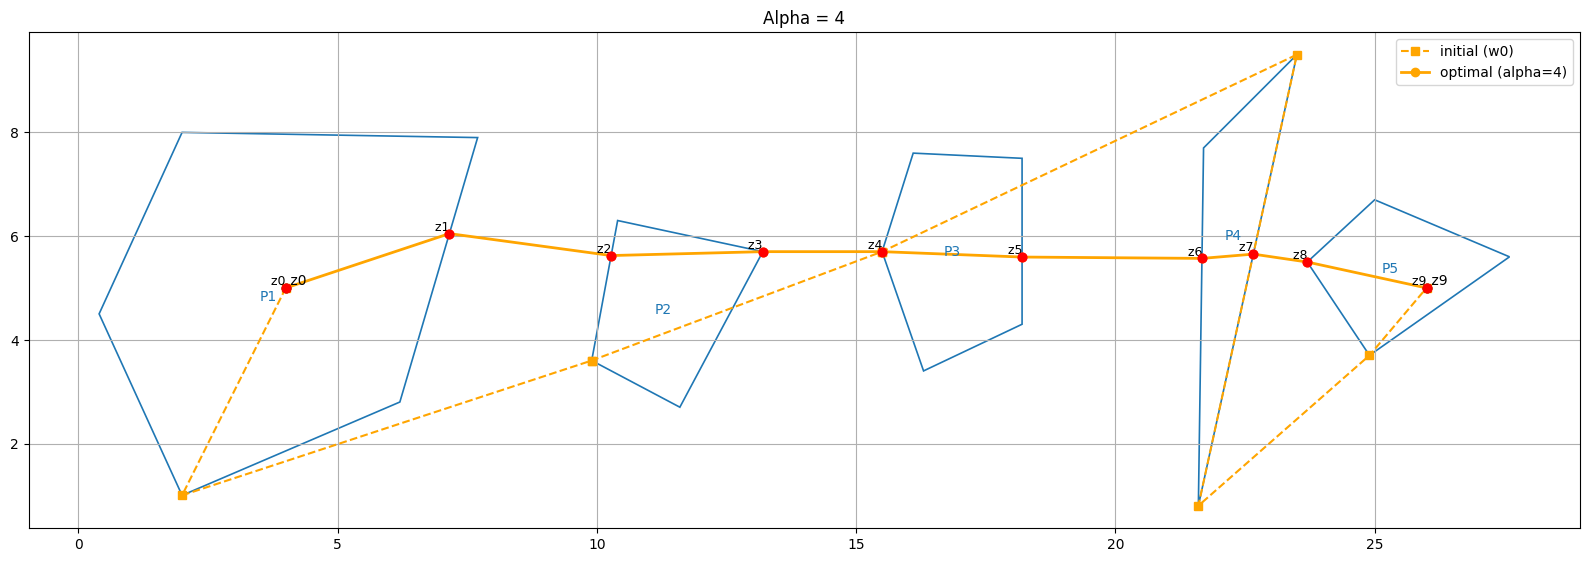

In [7]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from operator import eq
from matplotlib.patches import Polygon as MplPolygon

n = 16 # number of variables x1,y1, x2,y2, ... , x8,y8
def solve_qp(G, c, A_ge=None, b_ge=None, A_e=None, b_e=None, tol=1e-12, tol_mult=1e-10, max_iter=500,
             polygons=None, z0_coords=None, z9_coords=None):
  """solves the QP q(w)=12*w^T @ G @ w + c^⊤ @ w where w ∈ R^n """

  print("We're in solve_qp")
  # --- normalize inputs: treat None as empty arrays with correct shapes ---
  if A_ge is None or A_ge.size == 0:
      A_ge = np.zeros((0, n))
      b_ge = np.zeros((0,))
  if A_e is None or A_e.size == 0:
      A_e = np.zeros((0, n))
      b_e = np.zeros((0,))

  # maybe here better to get I,E set of indices of ineqty and eqty contrs
  eq_mat_len = A_e.shape[0] # number of rows in eqty matrix
  ineq_mat_len = A_ge.shape[0] # number of rows in ineqty matrix
  A_joined = np.vstack([A_e, A_ge])
  b_joined = np.concatenate([b_e, b_ge])
  print("number of equality constraints, rows of matrix A_e: ", eq_mat_len)
  print("number of inequality constraints, rows of matrix A_ge: ", ineq_mat_len)

  # small helpers
  def is_empty_matrix(M):
      return M.size == 0 or M.shape[0] == 0

  # separate only-equality-constrained qp solver function
  # KKT solver for only-equality-constrained qp to use in branch (c) and to compute step p in branch (d);
  def solve_KKT(G, c, Ae_sub, be_sub, eps_reg=1e-12):
    p_rows_Ae_sub = Ae_sub.shape[0]
    # building KKT matrix
    K = np.block([[G, -Ae_sub.T], [Ae_sub, np.zeros((p_rows_Ae_sub, p_rows_Ae_sub))]])
    rhs = np.concatenate([-c, be_sub])
    try:
        sol = np.linalg.solve(K, rhs)
    except np.linalg.LinAlgError:
        # try tiny regularization on G
        G_reg = G + eps_reg * np.eye(G.shape[0])
        K = np.block([[G_reg, -Ae_sub.T], [Ae_sub, np.zeros((p_rows_Ae_sub, p_rows_Ae_sub))]])
        sol = np.linalg.solve(K, rhs)
    p = sol[:G.shape[0]]
    # optional multipliers: lam = sol[n:]
    lam = sol[G.shape[0]:]
    return p, lam

  def select_linearly_independent_subset(A_joined_local, active_indices_local, tol_rank=1e-12):
    W_independent = []
    A_current = np.zeros((0, A_joined_local.shape[1])) # Corrected initialization
    for idx in active_indices_local:
        row = A_joined_local[idx:idx+1, :]
        A_test = np.vstack([A_current, row])
        if np.linalg.matrix_rank(A_test, tol_rank) > np.linalg.matrix_rank(A_current, tol_rank):
            A_current = A_test
            W_independent.append(idx)
    return W_independent


  def initial_working_set(x0, A_joined_local, b_joined_local, tol_active=1e-10):

    # keep track of indices of active rows of A_joined_local[A_e, A_ge] constraints at x0, first A_e rows already active so adding them at initialization
    active_indices = list(range(eq_mat_len))
    for i in range(eq_mat_len, eq_mat_len+ineq_mat_len):
        viol = A_joined_local[i].dot(x0) - b_joined_local[i]
        if abs(viol) <= tol_active:
            active_indices.append(i)

    W_independent = select_linearly_independent_subset(A_joined_local, active_indices)
    return W_independent

  # Finding step-length param alpha and the corresponding blocking constraint index (argmin) if any.
  def compute_step_length(xk, p, A_joined_local, b_joined_local, W_local, tol=1e-12):
    m_total = A_joined_local.shape[0]
    alpha = 1.0
    blocking_index = None
    W_set = set(W_local)
    for i in range(m_total):
        if i in W_set: # Only consider constraints not currently in the working set
            continue
        ai = A_joined_local[i]
        denom = ai.dot(p)
        if denom < -tol:   # moving forward in direction p decreases ai^T x (potential blocking constraint)
            num = b_joined_local[i] - ai.dot(xk)
            alpha_i = num / denom
            if alpha_i < alpha: # Find the smallest positive alpha
                alpha = alpha_i
                blocking_index = i
    # guard: alpha must be in [0,1]
    alpha = max(0.0, min(1.0, alpha))
    return alpha, blocking_index


  # Branch detection
  eps_G = 1e-12
  G_norm = np.linalg.norm(G, ord=np.inf)
  # symmetrize G to avoid tiny asymmetries
  G = 0.5 * (G + G.T)

  if G_norm < eps_G: # branch (a) when G is zero or has very small norm (LP case)
    print("we're in LP, branch a")
    res = opt.linprog(c, A_ub=-A_ge, b_ub=-b_ge, A_eq=A_e, b_eq=b_e, method='highs')
    if not res.success: raise RuntimeError("LP failed: " + res.message)
    return {"optimal_w": res.x, "status": "optimal", "iterations": res.nit, "active_set": None} # Return dictionary

  elif A_ge.shape == (0,n) and A_e.shape == (0, n): # branch (b) unconstrained QP
    print("we're in unconstrained QP, branch b")
    try:
        w = np.linalg.solve(G, -c)
        # A simple check for stationarity, though for unconstrained, this is the solution
        if np.linalg.norm(G @ w + c) > tol: # Check if residual is small
          raise np.linalg.LinAlgError("Residual too large, G might be singular/ill-conditioned")
    except np.linalg.LinAlgError:
        w = -np.linalg.pinv(G) @ c # if G is singular, use pseudoinverse
        if np.linalg.norm(G @ w + c) > tol: # Check residual again
            raise RuntimeError("Unconstrained QP: Solution from pinv also has large residual.")
    return {"optimal_w": w, "status": "optimal", "iterations": 1, "active_set": None} # Return dictionary

  elif A_ge.shape == (0,n) and A_e.shape[0] > 0: # branch (c) equality-only QP
    print("we're in equality-only QP, branch c")
    # w, lam = solve_equality_cons_qp(A_e)
    w, lam = solve_KKT(G=G, c=c, Ae_sub=A_e, be_sub=b_e)
    return {"optimal_w": w, "status": "optimal", "iterations": 1, "active_set": None} # Return dictionary

  else: # branch (d) inequality QP, solve active-set
    # print("we're in branch d, having inequality constrs, so solve active-set")

    # Helper for mapping k to polygon index
    def poly_map_func(k):  # k = 1..8 -> polygon index 0..4
        return (k-1)//2  # integer division

    # 1. choose a starting point x0 (Phase I)
    w0 = get_initial_feasible_point(A_ge=A_ge, b_ge=b_ge, Ae=A_e, be=b_e, polygons=polygons, z0=z0_coords, z9=z9_coords)[0]
    # w0 = get_centroid(polygons=polygons)
    xk = w0  # feasible initial point
    W = initial_working_set(xk, A_joined, b_joined)

    for it in range(max_iter):
      gk = G.dot(xk) + c
      A_working = A_joined[W, :]
      b_working = np.zeros(len(W)) # for finding direction p, A_working p = 0
      p, lam = solve_KKT(G=G, c=gk, Ae_sub=A_working, be_sub=b_working)

      if np.linalg.norm(p) < tol: # If step direction is negligible, check KKT multipliers
        nu_W = lam[eq_mat_len:] # Multipliers for active inequality constraints (indices beyond eq_mat_len)

        if np.all(nu_W >= -tol_mult): # Optimality condition met
          return {"initial_w0": w0, "optimal_w": xk, "status": "optimal", "iterations": it + 1, "active_set": np.array(W) - eq_mat_len} # Return dictionary
        else:
          # Remove most negative multiplier from W to make it inactive
          idx_drop = np.argmin(nu_W)
          # The index in W corresponding to the most negative nu_W
          original_constraint_idx_in_W = eq_mat_len + idx_drop
          constraint_to_remove = W[original_constraint_idx_in_W]
          W.remove(constraint_to_remove)
          continue # Continue to next iteration
      else: # Step direction p is significant, so take a step
        alpha, blocking_index = compute_step_length(xk=xk, p=p, A_joined_local=A_joined, b_joined_local=b_joined, W_local=W)
        xk = xk + alpha * p

        if blocking_index is not None and alpha < 1.0 - 1e-12: # If a new constraint became active (and alpha < 1)
          newW = W + [blocking_index]
          W = select_linearly_independent_subset(A_joined, newW)
        continue # Continue to next iteration

    # If max_iter is reached without finding an optimal solution
    # This part is reached if the loop finishes without an optimal return
    return {"initial_w0": w0, "optimal_w": xk, "status": "max_iterations_reached", "iterations": max_iter, "active_set": np.array(W) - eq_mat_len}

if __name__ == "__main__":
  # Define fixed coordinates as per problem statement
  z0 = (4, 5)
  z9 = (26, 5)

  # Polygons defined
  p0 = [(2, 1), (6.2, 2.8), (7.7, 7.9), (2, 8), (0.4, 4.5)]
  p1 = [(9.9, 3.6), (11.6, 2.7), (13.2, 5.7), (10.4, 6.3)]
#   p1 = [(11.6, 2.7), (13.2, 5.7)]
  p2 = [(15.5, 5.7), (16.3, 3.4), (18.2, 4.3), (18.2, 7.5), (16.1, 7.6)]
  p3 = [(21.6, 0.8), (23.5, 9.5), (21.7, 7.7)] # Reverting p3 to a 3-vertex polygon for inequality setup
#   p3 = [(21.6, 0.8), (23.5, 9.5)] # This makes it an equality constraint (a line segment)
  p4 = [(23.7, 5.5), (24.9, 3.7), (27.6, 5.6), (25, 6.7)]

  polygons = [p0, p1, p2, p3, p4]

  # Call the function with actual fixed coordinates
  G, c, A_ge, b_ge, Ae, be  = build_QP_matrices(polygons, alpha=4, beta=1, z0_coords=z0, z9_coords=z9)
#   G = np.zeros((n,n), dtype=dtype) # to force solve_qp fall into branch (a), linear problem case G=0
#   Ae = np.zeros((0, n)) # to force solve_qp fall into branch (b), unconstrained quad problem case A_ge, Ae = None or empty
  A_ge = np.zeros((0, n)) # to force solve_qp fall into branch (c), only equality quad problem case A_ge = None or empty
  # c_test = np.zeros(n, dtype=dtype)

  res = solve_qp(G, c, A_ge, b_ge, Ae, be, polygons=polygons, z0_coords=z0, z9_coords=z9)

  # Safely access dictionary elements
  w0 = res.get("initial_w0")
  w_opt = res.get("optimal_w")
  print("w0: ", w0)
  print("w_opt: ", w_opt)
  # if w_opt is not None and w0 is not None:
  #     print("Difference (w0 - w_opt):")
  #     print(w0 - w_opt)
  # else:
  #     print("Optimal solution or initial point not available in result.")

  ###
  # --- plotting helper (drop into your if __name__ == "__main__": block) ---
  plot_different_alphas(polygons, z0, z9, alphas=[4], colors=["orange"])


In [4]:
# Install mplcursors in the current Colab environment
!pip install -q mplcursors

# then import and re-run your plotting cell (no runtime restart required usually)
import mplcursors
print("mplcursors version:", mplcursors.__version__)


mplcursors version: 0.7


# **Task 4 — Solving the Transmission Line Problem for Multiple Values of** $ \alpha \ge \beta $

We solve the quadratic program with fixed  
$
z_0 = (4, 5), \qquad z_9 = (26, 5), \qquad \beta = 1,
$
and evaluate the effect of increasing  
$
\alpha \in \{1,\, 3,\, 5\}.
$

All intermediate points are encoded in the vector  
$
w = (x_1, y_1, x_2, y_2, \dots, x_8, y_8) \in \mathbb{R}^{16},
$
so that the full path is  
$
(z_0, z_1, z_2, \dots, z_8, z_9).
$

The QP is built using the function  
`build_QP_matrices(polygons, alpha, beta, z0, z9)`  
and solved with  
`solve_qp(G, c, A_ge, b_ge, Ae, be)`.

For each value of $ \alpha $, we record:

- the initial path  
  $
  w_0 = \text{initial\_w0}
  $
- the optimal path  
  $
  w^\star = \text{optimal\_w}
  $

Both printed as flat vectors in the order  
$
[x_1, y_1, x_2, y_2, \ldots, x_8, y_8].
$

The function `plot_different_alphas` shows:

- polygons $P_0, \dots, P_4$
- initial path (dashed)
- optimized path (solid)
- labeled nodes $z_0, \dots, z_9$

Increasing $ \alpha $ makes the optimization emphasize **smoothness**, which typically produces a straighter, less oscillatory path.


---

# **Task 5 — Introducing Equality Constraints (Line Segment Polyhedron)**

To test the solver’s ability to handle **equality constraints**, we modify one polygon to be a **line segment**.

Specifically, we replace
$
P_1 = [(9.9,3.6), (11.6,2.7), (13.2,5.7), (10.4,6.3)]
$
with a 2-vertex polyhedron:
$
P_1 = [(11.6, 2.7),\; (13.2, 5.7)],
$
and similarly convert  
$
P_3 = [(21.6, 0.8),\; (23.5, 9.5)]
$
into another line segment.

A polygon with exactly **two vertices** is interpreted as an **equality constraint**:
$
A_e w = b_e,
$
which forces the corresponding intermediate point $z_k$ to lie exactly on that line.

This checks whether:

- the QP correctly builds equality matrices $(A_e, b_e)$
- the solver can simultaneously satisfy  
  - inequality constraints (other polygons), and  
  - equality constraints (line segments)

We solve the modified geometry using the same values
$
\alpha \in \{1, 3, 5\}.
$

The results show the expected behavior:

- Nodes corresponding to line-segment polyhedra lie exactly on the segment  
- Remaining polygons enforce inequality constraints  
- As $ \alpha $ grows, the optimized path becomes smoother while still satisfying equalities and inequalities.



In [5]:
def plot_different_alphas(polygons, z0, z9, alphas, colors, figsize=(10,6)):
    fig, axs = plt.subplots(len(alphas), 1, figsize=(16, 10), sharex=True, sharey=True)

    # Ensure axs is iterable even if only one subplot
    if len(alphas) == 1:
        axs = [axs]

    def extract_z_list_from_w(w, z0, z9):
        """
        Given w (length 16) with order [x1,y1,x2,y2,...,x8,y8],
        return list of 11 points [z0, z1, z2, ..., z8, z9] as (x,y) tuples.
        """
        zs = [tuple(z0)]
        for k in range(8):
            x = w[2*k]
            y = w[2*k + 1]
            zs.append((float(x), float(y)))
        zs.append(tuple(z9))
        return zs

    for i in range(len(alphas)):
        ax = axs[i] # Get the current subplot axis

        # Plot polygons
        for idx, poly in enumerate(polygons):
            poly_patch = MplPolygon(poly, closed=True, edgecolor="tab:blue",
                                    facecolor=(0,0,0,0), lw=1.2)
            ax.add_patch(poly_patch)
            # put polygon index text near its centroid
            verts = np.array(poly)
            cx, cy = verts.mean(axis=0)
            ax.text(cx, cy, f"P{idx+1}", color="tab:blue", fontsize=10, ha="center", va="center")

        # Plot fixed endpoints
        ax.scatter([z0[0]], [z0[1]], marker="o", color="black", zorder=5)
        ax.text(z0[0], z0[1], " z0", va="bottom", ha="left")
        ax.scatter([z9[0]], [z9[1]], marker="o", color="black", zorder=5)
        ax.text(z9[0], z9[1], " z9", va="bottom", ha="left")

        # Re-build QP matrices for the current alpha
        G, c, A_ge, b_ge, Ae, be  = build_QP_matrices(polygons, alpha=alphas[i], beta=1, z0_coords=z0, z9_coords=z9)
        # Solve QP for the current alpha
        res = solve_qp(G, c, A_ge, b_ge, Ae, be, polygons=polygons, z0_coords=z0, z9_coords=z9)

        w0 = res.get("initial_w0", None)
        w_opt = res.get("optimal_w", None)
        print("w0:", w0)
        print("w_opt:", w_opt)

        # in case w0 or w_opt are numpy arrays stored inside lists or other types, coerce:
        if w0 is not None:
            w0 = np.asarray(w0, dtype=float)
        if w_opt is not None:
            w_opt = np.asarray(w_opt, dtype=float)

        # Plot initial path (dashed) and optimal path (solid)
        handles = []
        labels = []
        if w0 is not None:
            zs0 = extract_z_list_from_w(w0, z0, z9)
            xs0 = [p[0] for p in zs0]
            ys0 = [p[1] for p in zs0]
            h0, = ax.plot(xs0, ys0, linestyle="--", marker="s", markersize=6,
                          color=colors[i], linewidth=1.5, label="initial (w0)")
            handles.append(h0); labels.append("initial (w0)")

        if w_opt is not None:
            zso = extract_z_list_from_w(w_opt, z0, z9)
            xso = [p[0] for p in zso]
            yso = [p[1] for p in zso]
            ho, = ax.plot(xso, yso, linestyle="-", marker="o", markersize=6,
                          color=colors[i], linewidth=2.0, label=f"optimal (alpha={alphas[i]})")
            handles.append(ho); labels.append(f"optimal (alpha={alphas[i]})")

        # Scatter all nodes (z0..z9) for interactive hover
        base_w = w_opt if w_opt is not None else w0
        if base_w is not None:
            zs = extract_z_list_from_w(base_w, z0, z9)
        else:
            # fallback: use centroids of polygons for intermediate nodes
            zs = [tuple(z0)]
            for poly in polygons:
                verts = np.array(poly)
                zs.append((float(verts[:,0].mean()), float(verts[:,1].mean())))
            zs.append(tuple(z9))

        xs = [p[0] for p in zs]
        ys = [p[1] for p in zs]
        sc = ax.scatter(xs, ys, c="red", s=40, zorder=6)

        # Add textual labels near points (z0..z9)
        for k, (xk, yk) in enumerate(zs):
            ax.text(xk, yk, f" z{k}", color="black", fontsize=9, va="bottom", ha="right")

        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f"Alpha = {alphas[i]}")
        ax.legend(handles=handles, labels=labels)

        # Try to enable interactive hover-tooltips with mplcursors if available
        try:
            import mplcursors
            cursor = mplcursors.cursor(sc, hover=True)
            @cursor.connect("add")
            def on_add(sel):
                i_sel = sel.index
                label = f"z{i_sel}: ({xs[i_sel]:.3f}, {ys[i_sel]:.3f})"
                sel.annotation.set_text(label)
                sel.annotation.get_bbox_patch().set_alpha(0.9)
        except Exception as e:
            print("mplcursors not available; install with `pip install mplcursors` to enable hover tooltips.")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

We're in solve_qp
number of equality constraints, rows of matrix A_e:  4
number of inequality constraints, rows of matrix A_ge:  19
w0: [ 3.66   4.84  12.4    4.2   12.4    4.2   16.86   5.7   16.86   5.7
 22.55   5.15  22.55   5.15  25.3    5.375]
w_opt: [ 6.72752551  4.59358675 11.99477165  3.44019685 12.6823044   4.72932075
 15.84917105  4.69613324 18.2         4.37910653 22.31240824  4.06207982
 22.43353487  4.61671232 24.21676744  4.80835616]
We're in solve_qp
number of equality constraints, rows of matrix A_e:  4
number of inequality constraints, rows of matrix A_ge:  19
w0: [ 3.66   4.84  12.4    4.2   12.4    4.2   16.86   5.7   16.86   5.7
 22.55   5.15  22.55   5.15  25.3    5.375]
w_opt: [ 6.63888363  4.29220433 11.67184241  2.83470452 13.19996752  5.69993911
 15.5         5.7        18.2         4.36834235 22.28235256  3.92445646
 22.56229679  5.20630635 23.77373168  5.38940248]
We're in solve_qp
number of equality constraints, rows of matrix A_e:  4
number of inequality co

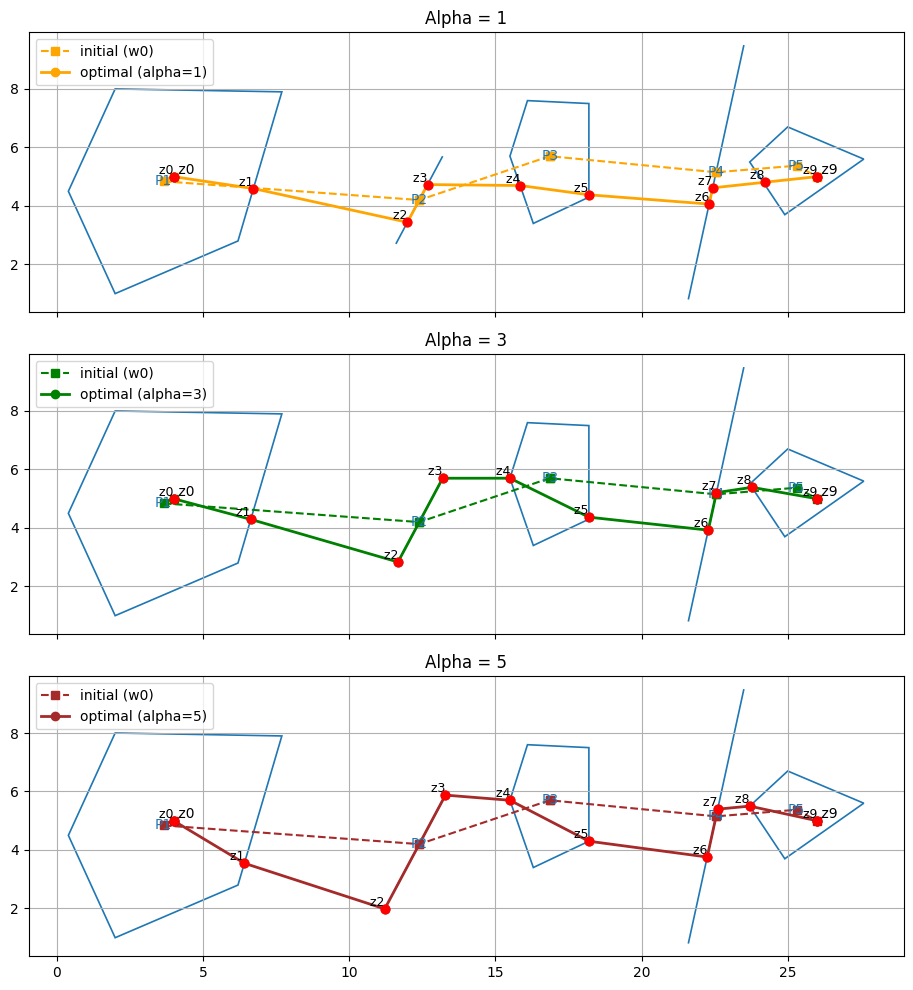

In [6]:
# Define fixed coordinates as per problem statement
z0 = (4, 5)
z9 = (26, 5)

# Polygons defined
p0 = [(2, 1), (6.2, 2.8), (7.7, 7.9), (2, 8), (0.4, 4.5)]
# p1 = [(9.9, 3.6), (11.6, 2.7), (13.2, 5.7), (10.4, 6.3)]
p1 = [(11.6, 2.7), (13.2, 5.7)]
p2 = [(15.5, 5.7), (16.3, 3.4), (18.2, 4.3), (18.2, 7.5), (16.1, 7.6)]
# p3 = [(21.6, 0.8), (23.5, 9.5), (21.7, 7.7)] # Reverting p3 to a 3-vertex polygon for inequality setup
p3 = [(21.6, 0.8), (23.5, 9.5)] # This makes it an equality constraint (a line segment)
p4 = [(23.7, 5.5), (24.9, 3.7), (27.6, 5.6), (25, 6.7)]

polygons = [p0, p1, p2, p3, p4]

alphas = [1, 3, 5]
colors = ['orange', 'green', 'brown']
plot_different_alphas(polygons, z0, z9, alphas, colors)

# **Task 6 — Short Report on Tasks 1, 4, and 5**

In **Task 1**, we established that the objective function is **convex** over each closed polygonal region. Because convexity holds on a closed and bounded domain, a global minimizer $w_{\text{optim}}$ is guaranteed to exist. This theoretical result justifies the optimization procedure used later.

In **Task 4**, we implemented a robust strategy for obtaining an initial point $w_0$. Since polygon boundaries can be sharp and linear, Phas I LP initialization may fail. To avoid this, we adopted a derivative-free methods' starting point initilization idea: choosing $w_0$ as a **centroid-type point** inside each polygon. This ensures the algorithm starts from a stable interior point and avoids geometric degeneracies.

In **Task 5**, we observed a consistent pattern: as the parameter $\alpha$ increases (recall that $\alpha$ models energy loss outside the communities), the optimal path shifts **deeper inside** the community region where $\beta = 1$. This behavior is intuitive — when external energy loss becomes more expensive, the optimizer naturally prefers staying inside the high-energy (or low-loss) community. Hence, minimizing the total energy loss forces the solution path to concentrate within the community boundaries.

Additional minor observations include the stability of the path shape under small parameter changes and the smooth trade-off between $\alpha$ and the path curvature.


In [9]:
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

In [10]:
# !jupyter nbconvert --to pdf /content/project1_optim564.ipynb # to latex pdf

In [ ]:
# If pdf converting does NOT work, TRY HTML formatting instead export directly to PDF via HTML:
# This uses Chromium headless, not LaTeX, so it avoids these unrecognized symbol errors.
# But: --to pdf with LaTeX usually gives nicer formatting for equations:

# !pip install "nbconvert[webpdf]" playwright
# !playwright install chromium
# !jupyter nbconvert --to webpdf /content/project1_optim564.ipynb